In [2]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import distance

# This should eventually be moved to an __init__.py file 
sys.path.insert(0, './functions/')
sys.path.insert(0, './data/')
import read_data as rd
import cost 
import ammortization
import replacement
import constants
# import rev_alias

%matplotlib inline
%load_ext autoreload
%autoreload 2


In [3]:
plant_data, cost_data, cf_data, age_data, emisisons_data, pv_cf_data, wind_cf_data = rd.read_data(os.getcwd())
plant_data = rd.clean_plant_data(plant_data)

In [4]:
cost_dict = cost_data.to_dict("dict")
cf_dict = dict(zip(cf_data.index, cf_data.capacity_factor.values))
emissions_dict = dict(zip(emisisons_data.index, emisisons_data.co2_lb_per_mmbtu.values*constants.lb_kg*constants.kg_tonne/constants.mmbtu_btu))

In [5]:
points = plant_data.loc[:, ["lat", "lon"]].values
pv_locs = pv_cf_data[["latitude", "longitude"]].values
wind_locs = wind_cf_data[["latitude", "longitude"]].values

pv_cfs = replacement.select_cf(points, pv_locs, pv_cf_data["capacity_factor"].values)
wind_cfs = replacement.select_cf(points, wind_locs, wind_cf_data["capacity_factor"].values)

hold_dict = cf_dict.copy()
hold_dict["Solar"] = pv_cfs
hold_dict["Wind"] = wind_cfs


In [6]:
remaining_capital_vec = np.vectorize(cost.remaining_capital)
plant_data["remaining_cost"] = remaining_capital_vec(plant_data["primary_fuel"].map(cost_dict["capital_cost_per_kw"])*constants.mw_kw*plant_data["capacity"], 2017-plant_data["commissioning_year"], 0.06, 30)

plant_data["annual_cost"] = cost.total_cost(plant_data["primary_fuel"].map(cost_dict["variable_om_per_mwh"]),
                                        plant_data["primary_fuel"].map(cost_dict["fixed_om_per_kw_year"]),
                                        plant_data["primary_fuel"].map(cost_dict["fuel_price_per_btu"]),
                                        plant_data["primary_fuel"].map(cost_dict["capital_cost_per_kw"]),
                                        0.06,
                                        30,
                                        plant_data["generation"],
                                        plant_data["capacity"],
                                        plant_data["fuel_consumption"])

C:\Users\jonat\anaconda3\envs\MACC\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)
C:\Users\jonat\AppData\Local\Temp/ipykernel_34144/3649069185.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plant_data2["cum_red"] = np.cumsum(plant_data2["em_red"])


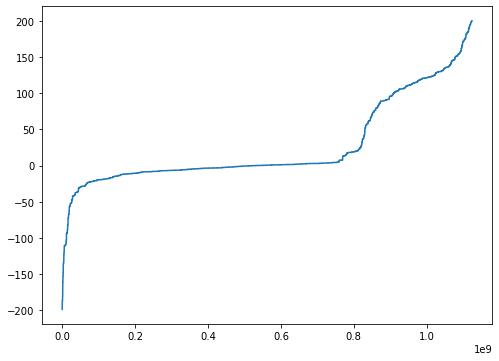

In [7]:
deletme = plant_data.copy()
deletme["rep_fuel"], deletme["metric"], deletme["em_red"] = replacement.replacement_iteration(plant_data["primary_fuel"].map(cost_dict["variable_om_per_mwh"]),
                                  plant_data["primary_fuel"].map(cost_dict["fixed_om_per_kw_year"]),
                                  plant_data["primary_fuel"].map(cost_dict["fuel_price_per_btu"]),
                                  0, # plant_data["primary_fuel"].map(cost_dict["capital_cost_per_kw"]),
                                  0.06,
                                  30,
                                  plant_data["generation"],
                                  plant_data["capacity"],
                                  plant_data["fuel_consumption"],
                                 2017-plant_data["commissioning_year"],
                                 plant_data["emissions"],
                                 # cf_dict,
                                 hold_dict,
                                 cost_dict,
                                 emissions_dict,
                                 metric = 1)

cap_val = 2e2
plant_data2 = deletme[deletme.metric.between(-cap_val, cap_val) & (deletme["em_red"] > 1)]
plant_data2.sort_values("metric", inplace = True)
plant_data2["cum_red"] = np.cumsum(plant_data2["em_red"])

# from matplotlib.patches import StepPatch

f, ax = plt.subplots(1, 1, figsize=(constants.PAGE_WIDTH, 2*constants.ROW_HEIGHT))
f.tight_layout()
# ax.hist(plant_data.metric)
ax.step(x = plant_data2.cum_red.values, y = plant_data2.metric, where = "pre")
# ax.set_yscale('log')
# ax.stairs(values = plant_data.metric, edges = np.insert(plant_data.cum_red.values, 0, 0), fill=True)

C:\Users\jonat\anaconda3\envs\MACC\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)
C:\Users\jonat\anaconda3\envs\MACC\lib\site-packages\pandas\core\indexing.py:1667: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value


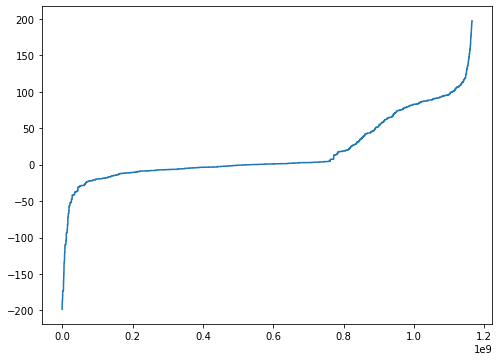

In [8]:
plant_data["rep_fuel"], plant_data["metric"], plant_data["em_red"] = replacement.replacement_iteration(plant_data["primary_fuel"].map(cost_dict["variable_om_per_mwh"]),
                                  plant_data["primary_fuel"].map(cost_dict["fixed_om_per_kw_year"]),
                                  plant_data["primary_fuel"].map(cost_dict["fuel_price_per_btu"]),
                                  0, # plant_data["primary_fuel"].map(cost_dict["capital_cost_per_kw"]),
                                  0.06,
                                  30,
                                  plant_data["generation"],
                                  plant_data["capacity"],
                                  plant_data["fuel_consumption"],
                                 2017-plant_data["commissioning_year"],
                                 plant_data["emissions"],
                                 cf_dict,
                                 # hold_dict,
                                 cost_dict,
                                 emissions_dict,
                                 metric = 1)
cap_val = 2e2
plant_data1 = plant_data[plant_data.metric.between(-cap_val, cap_val) & (plant_data["em_red"] > 1)]
plant_data1.sort_values("metric", inplace = True)
plant_data1.loc[:, "cum_red"] = np.cumsum(plant_data1["em_red"])

# from matplotlib.patches import StepPatch

f, ax = plt.subplots(1, 1, figsize=(constants.PAGE_WIDTH, 2*constants.ROW_HEIGHT))
f.tight_layout()
ax.step(x = plant_data1.cum_red.values, y = plant_data1.metric, where = "pre")

C:\Users\jonat\anaconda3\envs\MACC\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\jonat\AppData\Local\Temp/ipykernel_34144/1654130711.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\jonat\AppData\Local\Temp/ipykernel_34144/1654130711.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#ret

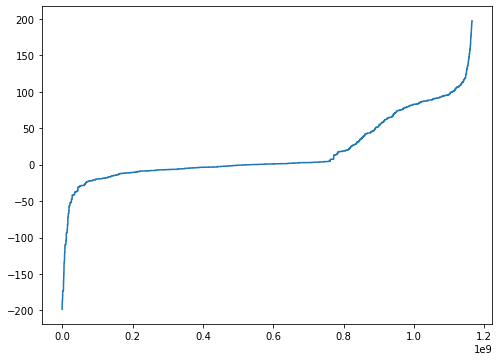

In [50]:
plant_data["rep_fuel"], plant_data["metric"], plant_data["em_red"] = replacement.replacement_iteration(plant_data["primary_fuel"].map(cost_dict["variable_om_per_mwh"]),
                                  plant_data["primary_fuel"].map(cost_dict["fixed_om_per_kw_year"]),
                                  plant_data["primary_fuel"].map(cost_dict["fuel_price_per_btu"]),
                                  0, # plant_data["primary_fuel"].map(cost_dict["capital_cost_per_kw"]),
                                  0.06,
                                  30,
                                  plant_data["generation"],
                                  plant_data["capacity"],
                                  plant_data["fuel_consumption"],
                                 2017-plant_data["commissioning_year"],
                                 plant_data["emissions"],
                                 cf_dict,
                                 # hold_dict,
                                 cost_dict,
                                 emissions_dict,
                                 metric = 1)
cap_val = 2e2
plant_data1 = plant_data[plant_data.metric.between(-cap_val, cap_val) & (plant_data["em_red"] > 1)]
plant_data1.sort_values("metric", inplace = True)
plant_data1["cum_red"] = np.cumsum(plant_data1["em_red"])
plant_data1["cum_red_prev"] = np.cumsum(plant_data1["em_red"])-plant_data1["em_red"]
plant_data1["ori_rep"] = plant_data1["primary_fuel"]+plant_data1["rep_fuel"]


# from matplotlib.patches import StepPatch

f, ax = plt.subplots(1, 1, figsize=(constants.PAGE_WIDTH, 2*constants.ROW_HEIGHT))
f.tight_layout()
# ax.hist(plant_data.metric)
ax.step(x = plant_data1.cum_red.values, y = plant_data1.metric, where = "pre")
# ax.set_yscale('log')
# ax.stairs(values = plant_data.metric, edges = np.insert(plant_data.cum_red.values, 0, 0), fill=True)

In [27]:
# x = np.arange(0,10)
# y = np.arange(0,10)
# color_ar = ["blue", "red", "red", "blue", "blue", "blue", "green", "green", "green"]

# f, ax = plt.subplots(1, 1, figsize=(constants.PAGE_WIDTH, 2*constants.ROW_HEIGHT))
# f.tight_layout()
# ax.fill_between(x, y, y2=0, step = "pre", set_facecolor = color_ar)
# ax.step(x = plant_data1.cum_red.values, y = plant_data1.metric, where = "pre")
plant_data1.head()



,name,state,lat,lon,commissioning_year,prime_mover,primary_fuel,capacity,generation,fuel_consumption,emissions,remaining_cost,annual_cost,rep_fuel,metric,em_red,cum_red,cum_red_prev
295,Carlls Corner,NJ,39.454700,-75.201400,1973,GT,Gas,82,9328000,233929.700,14247.700,0.0,8.473146e+06,Gas,-198.622665,10419.987676,10419.987676,0.000000
738,Comanche (OK),OK,34.543100,-98.324400,1962,CT,Gas,294,76077000,1090190.140,64788.238,0.0,3.045351e+07,Gas,-198.039546,33570.305920,43990.293596,10419.987676
526,Somerset Operating Co LLC,NY,43.358889,-78.604722,1984,ST,Coal,655,373156000,3592028.904,368542.190,0.0,1.975936e+08,Gas,-197.540172,215418.924580,259409.218176,43990.293596
219,Cleary Flood,MA,41.865300,-71.106100,1966,CA,Gas,146,62149000,658330.608,40489.111,0.0,1.516557e+07,Gas,-190.846641,14986.485228,274395.703404,259409.218176
291,Merrimack,NH,43.141100,-71.469200,1960,ST,Coal,494,268972000,2747922.556,281201.620,0.0,1.489269e+08,Gas,-188.746400,170829.896253,445225.599657,274395.703404


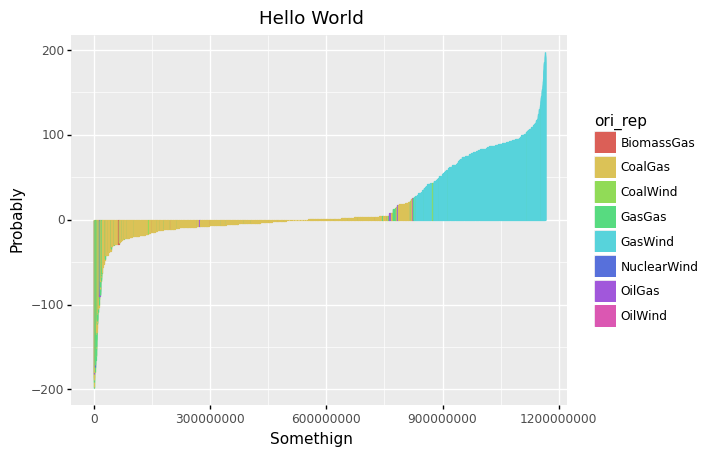

<ggplot: (161281379491)>

In [53]:
from plotnine import *

(
  ggplot(plant_data1) +
    aes(xmin = "cum_red_prev", 
                  xmax = "cum_red", 
                  ymin = 0, 
                  ymax = "metric",
        fill = "ori_rep", 
                  colour = "ori_rep")+
    geom_rect()+#,
                  # fill = ori_rep, 
                  # colour = ori_rep)) +
    # geom_label(aes(x = lab_xloc, y = lab_yloc, label = round(lab_val, 3)), size = 5)+
    ggtitle("Hello World") +
    xlab("Somethign") +
    ylab("Probably")
)